<a href="https://colab.research.google.com/github/Eddythemachine/intro_to_cnn/blob/main/intro_to_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Get Data

In [1]:
import zipfile

# Get File
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# Unzip
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

--2026-03-11 04:49:32--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.141.207, 142.251.2.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   132MB/s    in 0.8s    

2026-03-11 04:49:33 (132 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



In [2]:
!ls pizza_steak

test  train


In [3]:
!ls pizza_steak/train

pizza  steak


In [4]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [5]:
import os

# Wallkthrough pizza_steak directory and list number of files
for dirpath, dirnames, filenames, in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} in {dirpath}")

There are 2 in pizza_steak
There are 2 in pizza_steak/train
There are 0 in pizza_steak/train/steak
There are 0 in pizza_steak/train/pizza
There are 2 in pizza_steak/test
There are 0 in pizza_steak/test/steak
There are 0 in pizza_steak/test/pizza


In [6]:
# The extra file in our pizza_steak dir is ".Ds_Store"
!ls -la pizza_steak

total 16
drwxr-xr-x 4 root root 4096 Mar 11 04:49 .
drwxr-xr-x 1 root root 4096 Mar 11 04:49 ..
drwxr-xr-x 4 root root 4096 Mar 11 04:49 test
drwxr-xr-x 4 root root 4096 Mar 11 04:49 train


In [16]:
# Import matplotli
import matplotlib.pyplot as plt

num_steak_iamges_train = len(os.listdir("pizza_steak/train/steak"))
num_steak_iamges_train

750

In [17]:
# Get Class Names
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted((item.name for item in data_dir.glob("*"))))
print(class_names)

['pizza' 'steak']


In [18]:
# Visualise
import matplotlib.image as mpimg
import random
import os

def view_random_image(target_dir, target_class):
    # Set up target directory - ensure there is a slash between dir and class
    target_folder = os.path.join(target_dir, target_class)

    # Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)[0]
    img_path = os.path.join(target_folder, random_image)
    print(f"Reading image: {random_image}")

    # Read the image and plot using matplotlib
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")

    print(f"Image shape: {img.shape}")

    return img

Reading image: 732986.jpg
Image shape: (512, 512, 3)


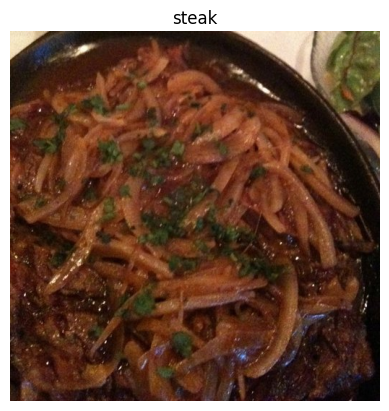

In [10]:
img = view_random_image(target_dir="pizza_steak/train",
                        target_class="steak")

In [11]:
import tensorflow as tf
tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[235, 221, 186],
        [231, 217, 182],
        [239, 225, 190],
        ...,
        [ 90,  87,  36],
        [115, 107,  60],
        [108, 100,  53]],

       [[241, 227, 192],
        [238, 224, 189],
        [244, 230, 195],
        ...,
        [122, 119,  68],
        [127, 121,  73],
        [114, 106,  59]],

       [[243, 229, 194],
        [241, 227, 192],
        [244, 230, 195],
        ...,
        [142, 138,  90],
        [139, 132,  86],
        [130, 123,  77]],

       ...,

       [[ 53,  26,  17],
        [ 51,  24,  15],
        [ 52,  25,  16],
        ...,
        [ 11,   6,  12],
        [ 11,   6,  12],
        [ 12,   7,  13]],

       [[ 60,  31,  23],
        [ 54,  27,  18],
        [ 53,  26,  17],
        ...,
        [ 11,   6,  12],
        [ 10,   5,  11],
        [ 11,   6,  12]],

       [[ 67,  38,  30],
        [ 57,  28,  20],
        [ 51,  24,  15],
        ...,
        [  9,   4,  1

In [12]:
# View image shape
img.shape

(512, 512, 3)

# An end to end example

In [19]:
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

print(f"Training directory: {train_dir}")
print(f"Testing directory: {test_dir}")

Training directory: pizza_steak/train
Testing directory: pizza_steak/test


In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Create ImageDataGenerator instances with rescaling
train_datagen = ImageDataGenerator(rescale=1./255)  # Changed to 1./255
test_datagen = ImageDataGenerator(rescale=1./255)

print(f"ImageDataGenerator instances created with rescale: {train_datagen.rescale}")

In [ ]:
# Import from directories
train_data = train_datagen.flow_from_directory(train_dir,
                                            batch_size=32,
                                            target_size=(224, 224),  # Added space
                                            class_mode='binary',
                                            seed=42)

valid_data = test_datagen.flow_from_directory(test_dir,
                                            batch_size=32,
                                            target_size=(224, 224),  # Added space
                                            class_mode='binary',
                                            seed=42)

In [25]:

# Build an optimized CNN model (Tiny VGG style but more efficient)
model_1 = tf.keras.models.Sequential([

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Block 4
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [26]:
model_1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_99 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_100 (Conv2D)             │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_98 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_102 (Conv2D)             │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_99 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_104 (Conv2D)             │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_100               │ (None, 28, 28, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_101               │ (None, 14, 14, 256)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │    25,690,62

 Total params: 26,999,457 (102.99 MB)

 Trainable params: 26,996,961 (102.99 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [27]:
# Compile Model with Adam optimizer (often better than SGD)
model_1.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [29]:
# Callbacks for better training
callbacks = [
    # Reduce learning rate when plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    # Early stopping to prevent overfitting
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Model checkpoint to save best model
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]


In [30]:
# Fit the model
history_1 = model_1.fit(
    train_data,
    epochs=50,  # Increased epochs with early stopping
    steps_per_epoch=len(train_data),
    validation_data=valid_data,
    callbacks=callbacks
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.6955 - loss: 0.7187
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 74s 931ms/step - accuracy: 0.6962 - loss: 0.7171 - val_accuracy: 0.5000 - val_loss: 3.7088 - learning_rate: 0.0010
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8147 - loss: 0.4601
Epoch 2: val_accuracy did not improve from 0.50000
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - accuracy: 0.8144 - loss: 0.4610 - val_accuracy: 0.5000 - val_loss: 2.9249 - learning_rate: 0.0010
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8207 - loss: 0.4334
Epoch 3: val_accuracy did not improve from 0.50000
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 212ms/step - accuracy: 0.8206 - loss: 0.4333 - val_accuracy: 0.5000 - val_loss: 2.8403 - learning_rate: 0.0010
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8220 - loss: 0.4337
Epoch 4: val_accuracy improved from 0.50000 to 0.50200, saving model to best_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 218ms/step - accuracy: 0.8220 - loss: 0.4336 - val_accuracy: 0.5020 - val_loss: 1.7594 - learning_rate: 0.0010
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8398 - loss: 0.3604
Epoch 5: val_accuracy improved from 0.50200 to 0.53600, saving model to best_model.h5


...

47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step - accuracy: 0.9818 - loss: 0.0603 - val_accuracy: 0.8560 - val_loss: 0.3682 - learning_rate: 4.0000e-05
Epoch 17/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9850 - loss: 0.0603
Epoch 17: val_accuracy improved from 0.85600 to 0.86000, saving model to best_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.9850 - loss: 0.0602 - val_accuracy: 0.8600 - val_loss: 0.3460 - learning_rate: 4.0000e-05
Epoch 18/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9890 - loss: 0.0478
Epoch 18: val_accuracy did not improve from 0.86000
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy: 0.9889 - loss: 0.0479 - val_accuracy: 0.8540 - val_loss: 0.3723 - learning_rate: 4.0000e-05
Epoch 19/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9884 - loss: 0.0436
Epoch 19: val_accuracy improved from 0.86000 to 0.86600, saving model to best_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 218ms/step - accuracy: 0.9884 - loss: 0.0436 - val_accuracy: 0.8660 - val_loss: 0.3454 - learning_rate: 4.0000e-05
Epoch 20/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9892 - loss: 0.0479
Epoch 20: val_accuracy did not improve from 0.86600
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 196ms/step - accuracy: 0.9890 - loss: 0.0480 - val_accuracy: 0.8660 - val_loss: 0.3346 - learning_rate: 4.0000e-05
Epoch 21/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9866 - loss: 0.0481
Epoch 21: val_accuracy improved from 0.86600 to 0.89000, saving model to best_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 222ms/step - accuracy: 0.9867 - loss: 0.0481 - val_accuracy: 0.8900 - val_loss: 0.2961 - learning_rate: 4.0000e-05
Epoch 22/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9935 - loss: 0.0354
Epoch 22: val_accuracy did not improve from 0.89000
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy: 0.9935 - loss: 0.0355 - val_accuracy: 0.8640 - val_loss: 0.3667 - learning_rate: 4.0000e-05
Epoch 23/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9832 - loss: 0.0532
Epoch 23: val_accuracy improved from 0.89000 to 0.90200, saving model to best_model.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 217ms/step - accuracy: 0.9831 - loss: 0.0533 - val_accuracy: 0.9020 - val_loss: 0.2648 - learning_rate: 4.0000e-05
Epoch 24/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9914 - loss: 0.0388
Epoch 24: val_accuracy did not improve from 0.90200
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.9914 - loss: 0.0388 - val_accuracy: 0.8920 - val_loss: 0.2724 - learning_rate: 4.0000e-05
Epoch 25/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9928 - loss: 0.0359
Epoch 25: val_accuracy did not improve from 0.90200
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.9927 - loss: 0.0361 - val_accuracy: 0.8920 - val_loss: 0.2924 - learning_rate: 4.0000e-05
Epoch 26/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9881 - loss: 0.0488
Epoch 26: val_accuracy did not improve from 0.90200
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step - accuracy: 0.9881 - loss: 0.0487 - val_accuracy: 0.8960 - val_loss: 0.2630 - learning_rate: 4.0000e-05
E

<Axes: xlabel='epochs'>

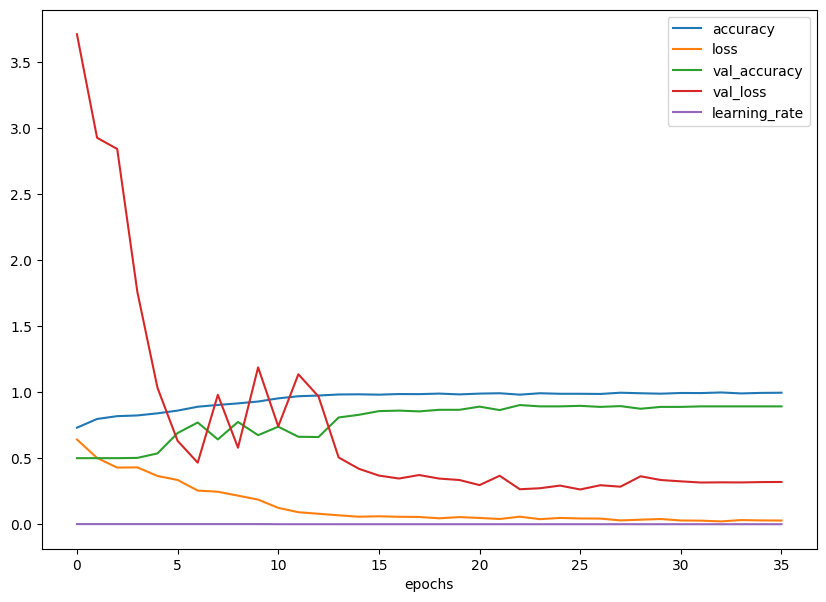

In [32]:
import pandas as pd
pd.DataFrame(history_1.history).plot(figsize=(10,7), xlabel="epochs")

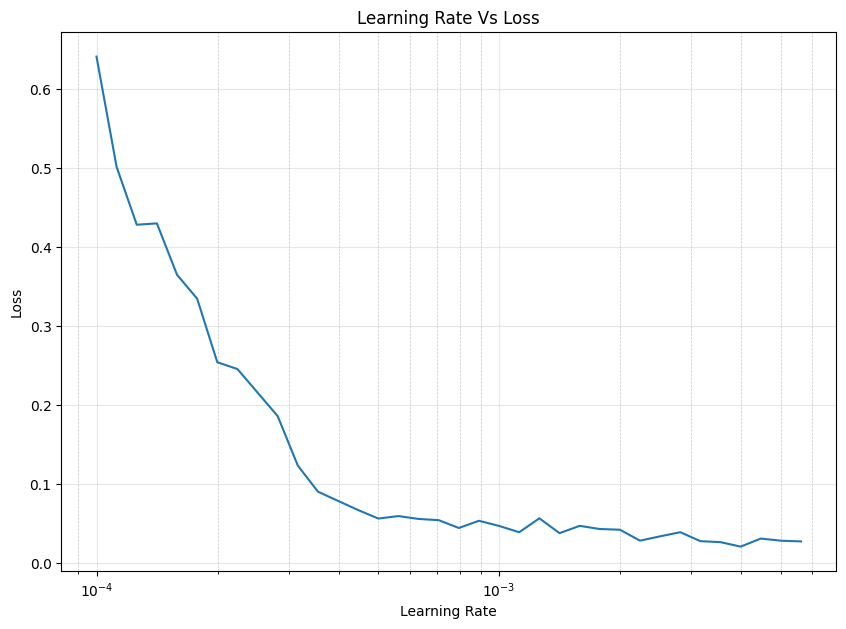

In [36]:
def plot_lr_vs_loss(history, num_lrs=100):
    """
    Plot Learning Rate vs Loss with grid
    """
    lrs = 1e-4 * (10 ** (tf.range(num_lrs)/20))

    plt.figure(figsize=(10,7))
    plt.semilogx(lrs[:len(history.history["loss"])], history.history["loss"])
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.title("Learning Rate Vs Loss")

    # Add grid
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.grid(True, which='major', linestyle='-', linewidth=0.8, alpha=0.3)

    plt.show()

# Use it
plot_lr_vs_loss(history_1)

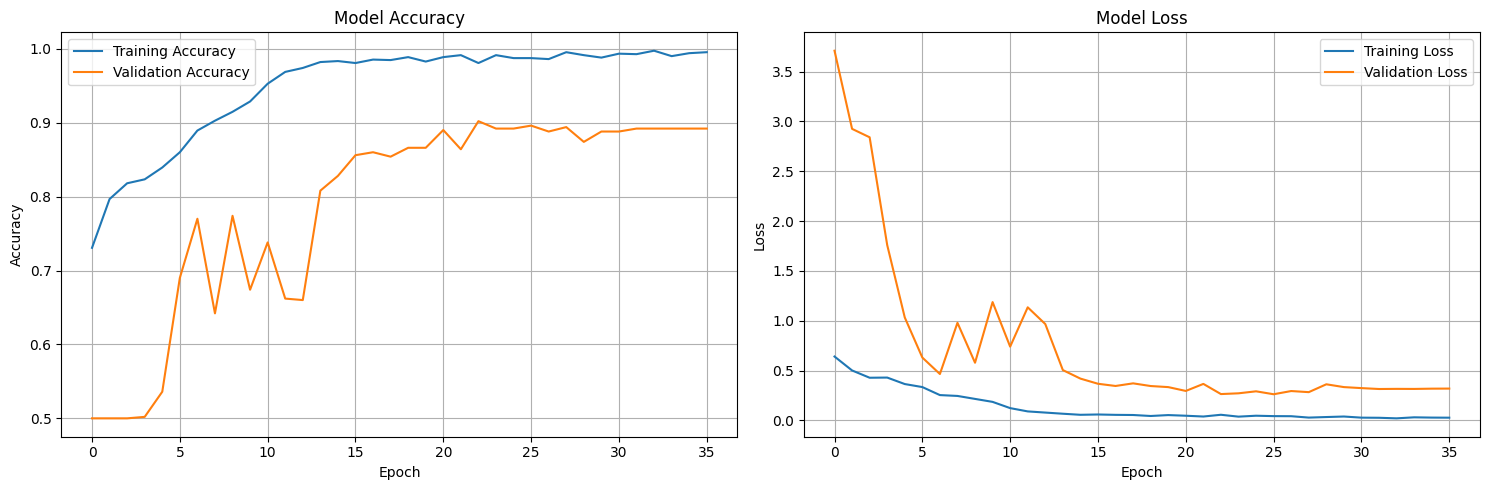

In [35]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot training & validation accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Plot training & validation loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history_1)

In [ ]:
Let